In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset
df = pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Type,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoids,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [5]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

There are no missing values in the dataset. Therefore, no data cleaning or imputation is required.

In [6]:
df.duplicated().sum()

np.int64(0)

There are no duplicate records in the dataset. Hence, no duplicate removal is required.

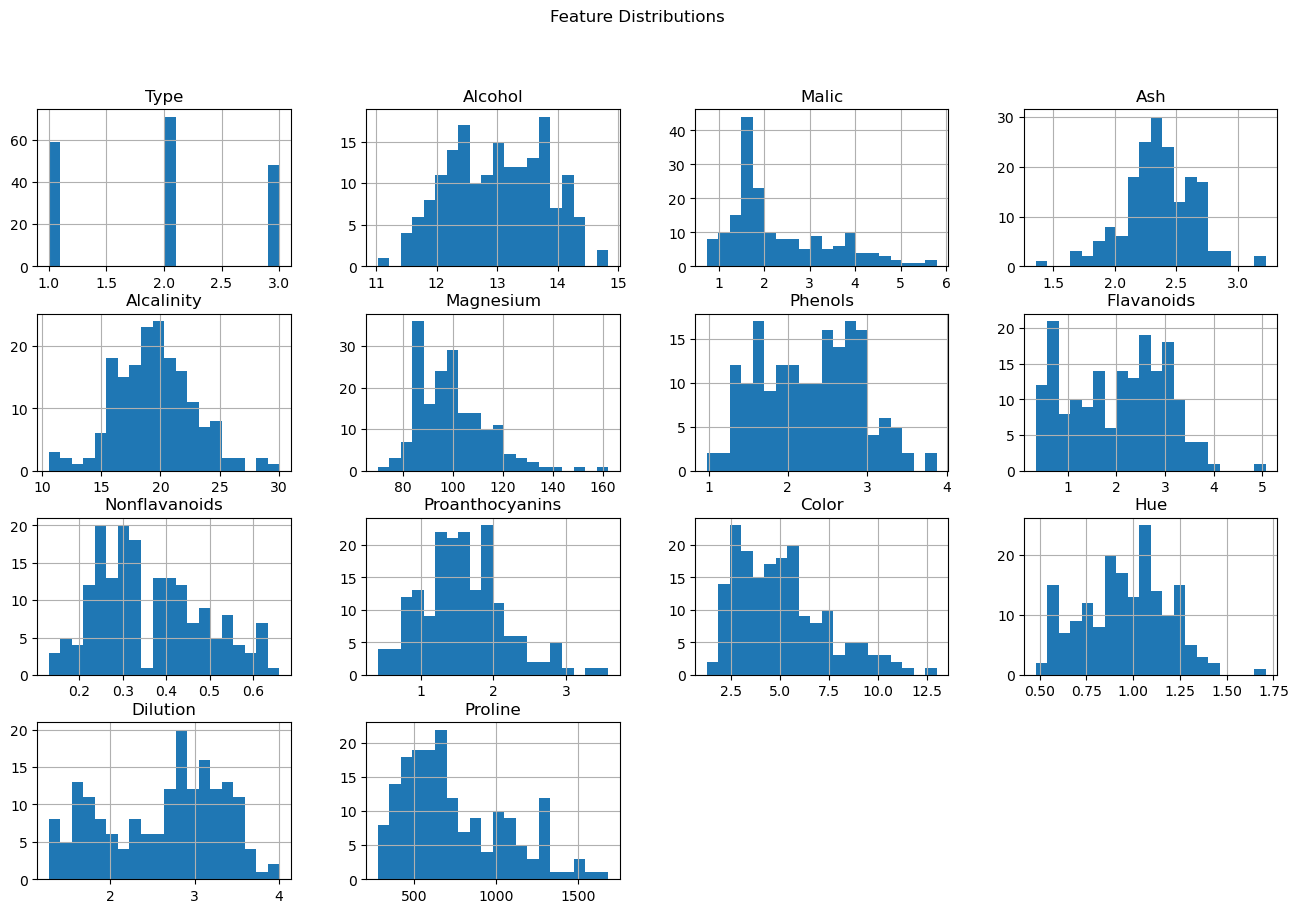

In [7]:
df.hist(bins=20, figsize=(16,10))
plt.suptitle("Feature Distributions")
plt.show()

- The histograms show that some features are normally distributed while others are slightly skewed. 
- This indicates that standardization is necessary before applying PCA.

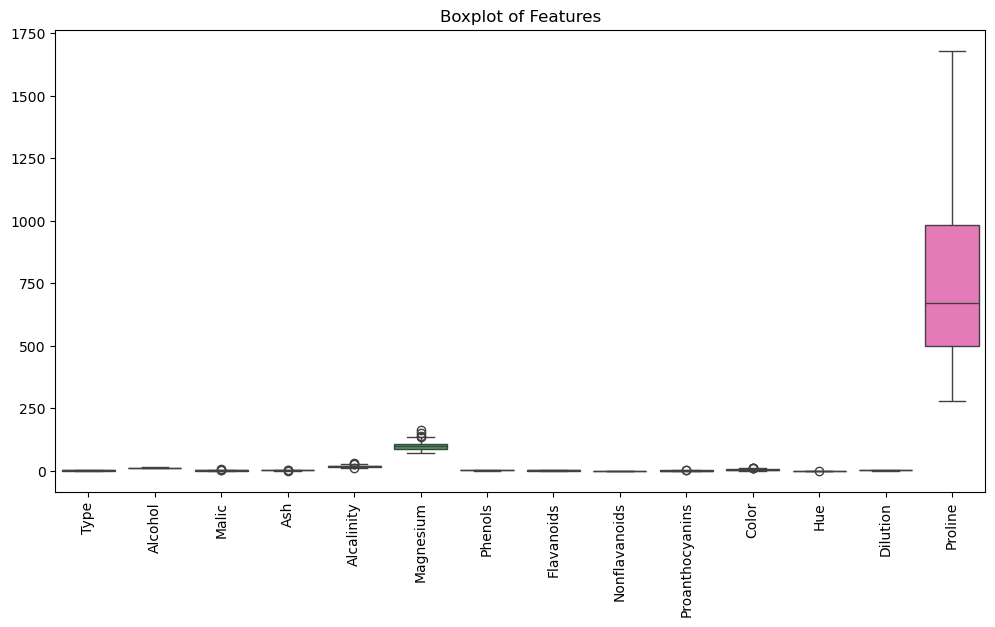

In [8]:
# Boxplots for all features
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.xticks(rotation=90)
plt.show()

The boxplot indicates large variation in Proline and Magnesium, with noticeable outliers across several features.

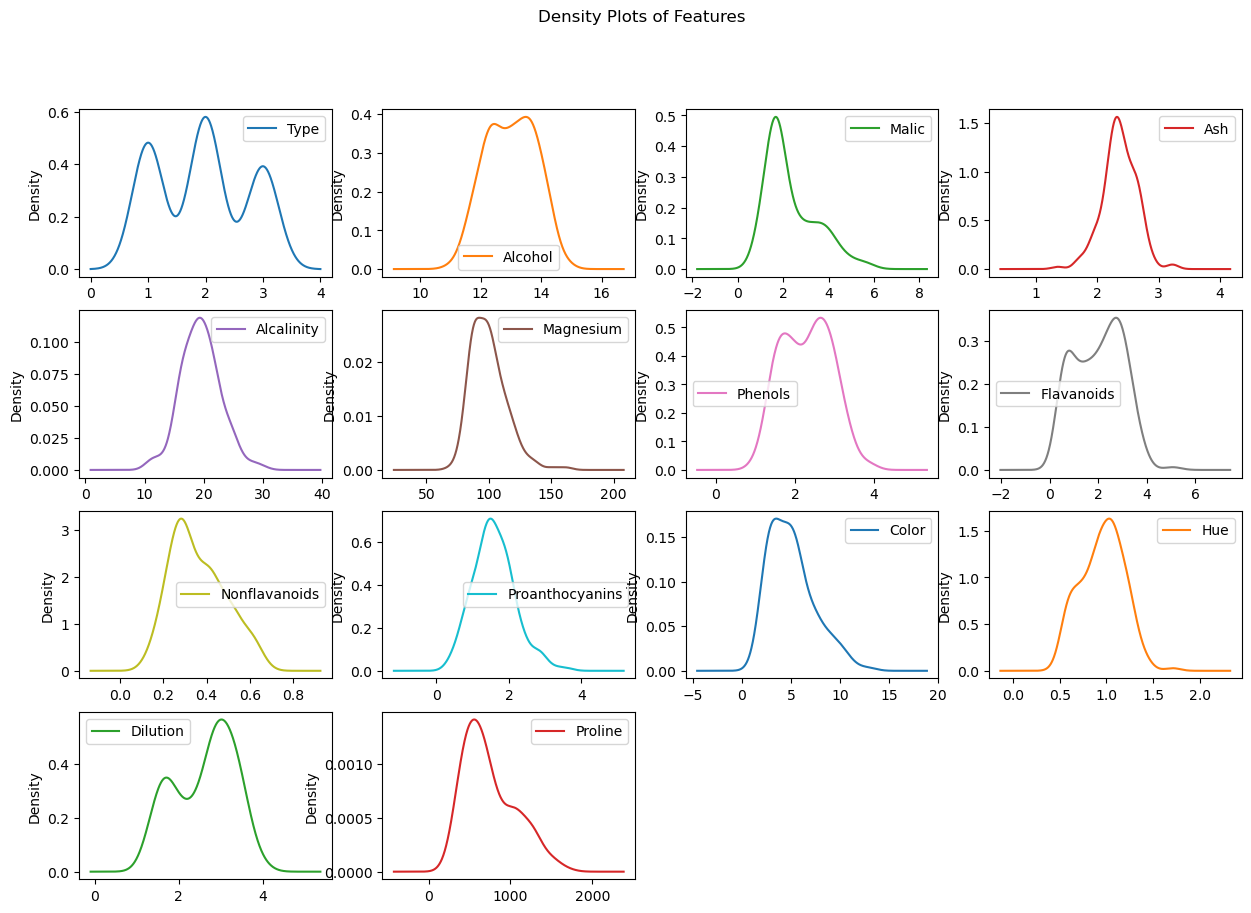

In [9]:
# Density plots for all features
df.plot(kind='density', subplots=True, layout=(4,4), sharex=False, figsize=(15,10))
plt.suptitle("Density Plots of Features")
plt.show()

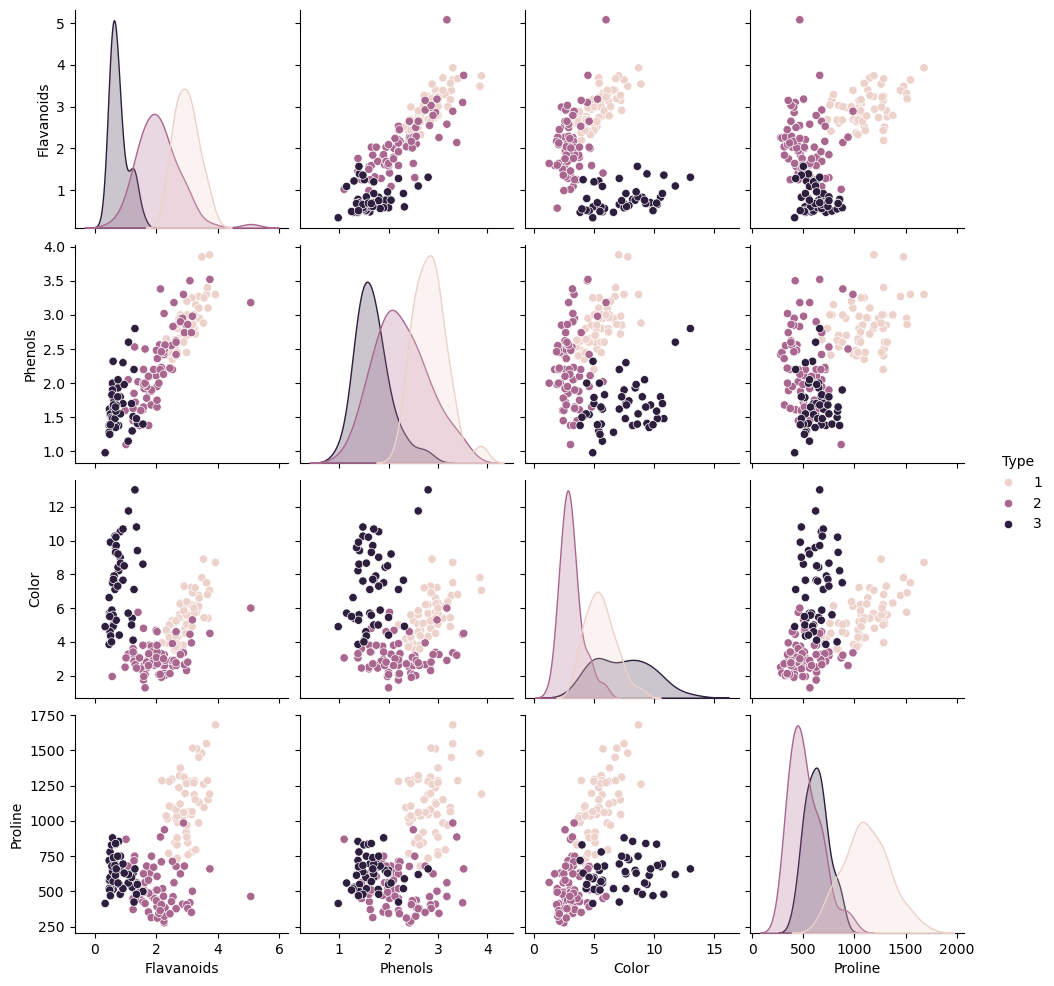

In [10]:
# Scatterplots for key relationships
sns.pairplot(df, vars=['Flavanoids', 'Phenols', 'Color', 'Proline'], hue='Type')
plt.show()

- The pairplot shows clear separation between wine types, especially using Flavanoids, Phenols, and Proline.
- Type 1 generally has higher Flavanoids and Proline, while Type 3 tends to have lower values, indicating strong class distinction.

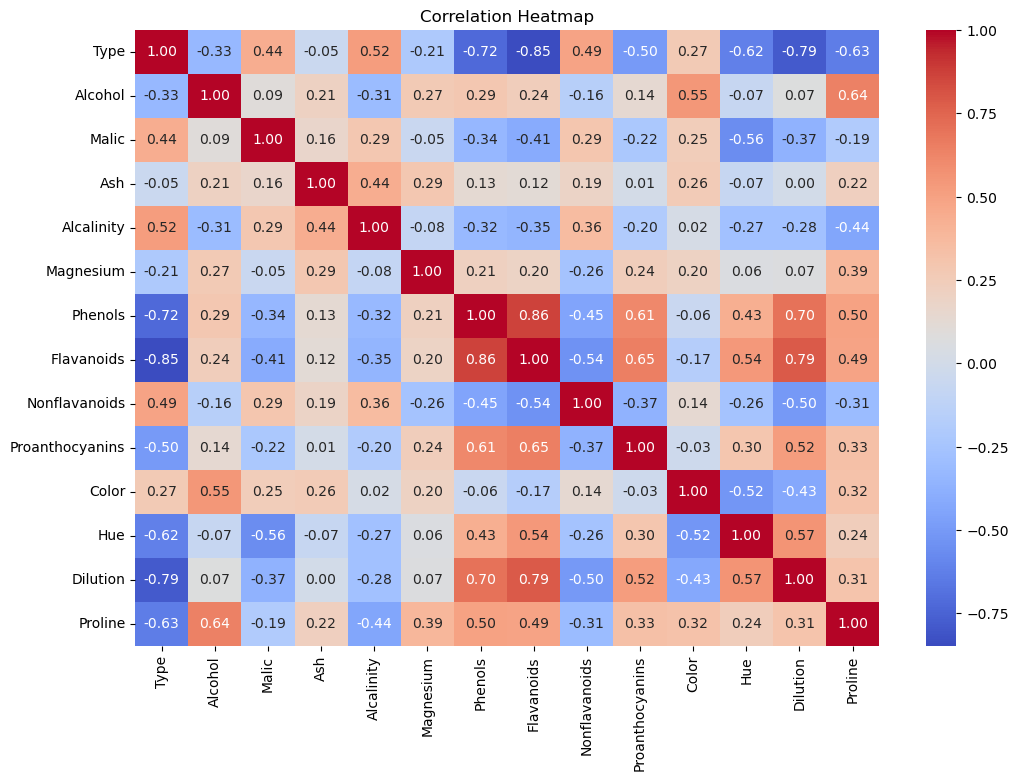

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- Strong positive correlations appear among Flavanoids, Phenols, and Dilution, while Type is negatively correlated with Flavanoids.
- Alcohol and Proline show moderate relationships with several features, suggesting their relevance.

## Task 2: Dimensionality Reduction with PCA

In [12]:
# Separate features and target
X = df.drop('Type', axis=1)
y = df['Type']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check mean and std after scaling
print("Mean after scaling (approx.):", X_scaled.mean(axis=0)[:5])
print("Std after scaling (approx.):", X_scaled.std(axis=0)[:5])

# Convert back to DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled.head()

Mean after scaling (approx.): [-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17]
Std after scaling (approx.): [1. 1. 1. 1. 1.]


,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [13]:
# Fit PCA to standardized features
pca = PCA()
pca.fit(X_scaled)

# Variance explained by each principal component
explained_variance = pca.explained_variance_ratio_

# Display explained variance
explained_variance

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

In [14]:
# Separate features (exclude 'Type')
X = df.drop('Type', axis=1).values

# Standardize only numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check mean and std after scaling
print("Mean after scaling (approx.):", X_scaled.mean(axis=0)[:5])
print("Std after scaling (approx.):", X_scaled.std(axis=0)[:5])

# Convert back to a DataFrame for convenience
df_scaled = pd.DataFrame(X_scaled, columns=df.drop('Type', axis=1).columns)
display(df_scaled.head())

Mean after scaling (approx.): [-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17]
Std after scaling (approx.): [1. 1. 1. 1. 1.]


,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


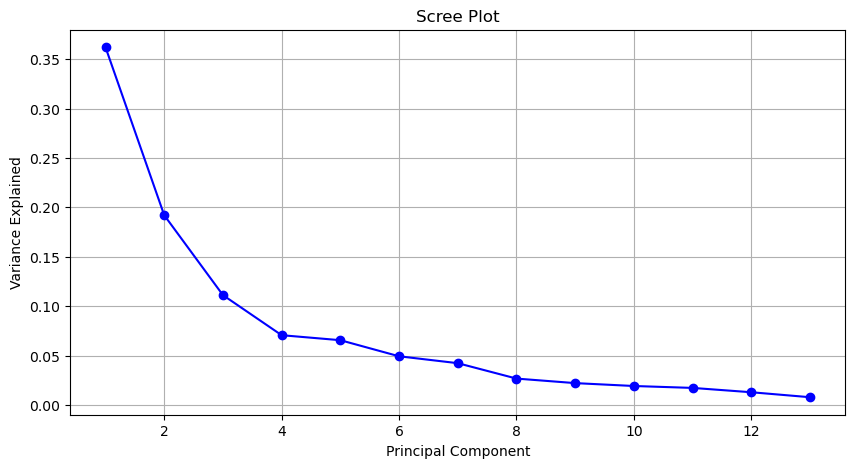

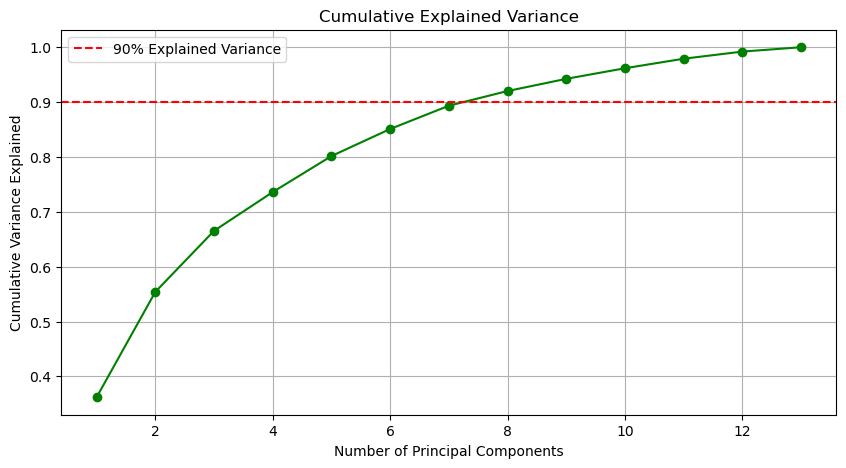

In [15]:
# Scree plot
plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(explained_variance)+1), explained_variance, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, 'o-', color='green')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

- The scree plot shows that most variance is explained by the first 2–3 principal components, indicating dimensionality can be reduced effectively.
- The cumulative plot shows that around 7–8 principal components are needed to capture about 90% of the total variance.

In [16]:
# Apply PCA with chosen components
pca_final = PCA(n_components=2)
X_pca = pca_final.fit_transform(X_scaled)

# Create a dataframe for PCA results
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
print(pca_df.head())

        PC1       PC2
0  3.316751  1.443463
1  2.209465 -0.333393
2  2.516740  1.031151
3  3.757066  2.756372
4  1.008908  0.869831


- The dataset has been successfully transformed into two principal components (PC1 and PC2).
- These components represent the directions of maximum variance in the data and will be used for clustering and visualization.

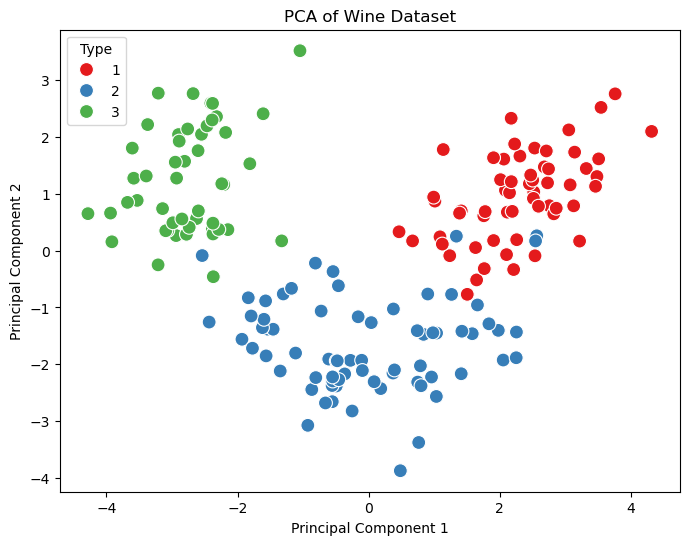

In [17]:
# Add Type column to PCA dataframe
pca_df['Type'] = df['Type']

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Type', data=pca_df, palette='Set1', s=100)
plt.title('PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

The PCA plot shows clear separation of the three wine types, indicating that the first two principal components effectively distinguish the classes.

## Task 3: Clustering with Original Data:

In [19]:
# Apply K-Means with 3 clusters (as wine dataset typically has 3 classes)
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
orig_labels = kmeans_orig.fit_predict(X_scaled)

# Add cluster labels to the dataframe (optional)
df['Cluster_Original'] = orig_labels

print("Cluster labels assigned to each sample:\n", df['Cluster_Original'].value_counts())
df.head()


Cluster labels assigned to each sample:
 Cluster_Original
0    65
2    62
1    51
Name: count, dtype: int64


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster_Original
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


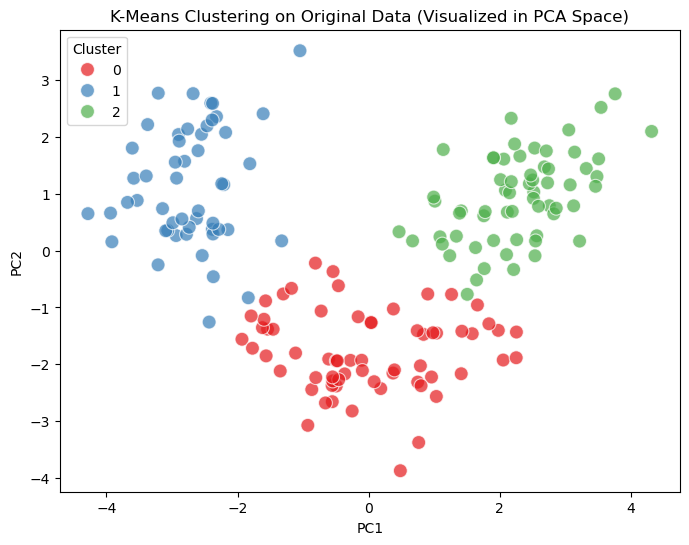

In [20]:
# Reduce to 2 principal components for visualization
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

# Create DataFrame for plotting
df_plot = pd.DataFrame(X_pca_vis, columns=['PC1', 'PC2'])
df_plot['Cluster'] = orig_labels   # use correct variable
df_plot['Type'] = df['Type']

# Scatter plot of clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_plot,
                palette='Set1', s=100, alpha=0.7)

plt.title('K-Means Clustering on Original Data (Visualized in PCA Space)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

The scatter plot shows the clusters formed by K-Means on the original standardized dataset. The clusters appear reasonably well separated in the reduced PCA space, indicating that K-Means has identified meaningful groupings.

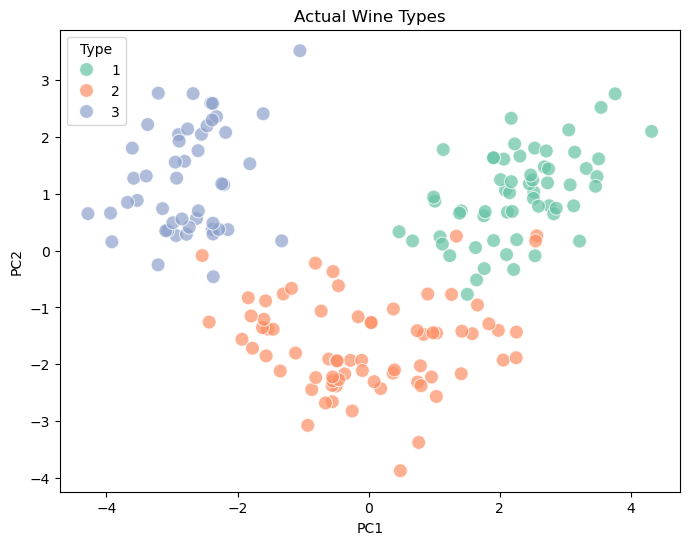

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Type', data=df_plot,
                palette='Set2', s=100, alpha=0.7)
plt.title('Actual Wine Types')
plt.show()

The scatter plot shows the actual wine types in PCA space. Comparing this with the clustering results helps assess how closely the K-Means algorithm has grouped the samples relative to their true classes.

In [22]:
# Evaluate clustering
sil_orig = silhouette_score(X_scaled, orig_labels)
db_orig = davies_bouldin_score(X_scaled, orig_labels)

print("Original Data - Silhouette Score:", sil_orig)
print("Original Data - Davies-Bouldin Index:", db_orig)

Original Data - Silhouette Score: 0.2848589191898987
Original Data - Davies-Bouldin Index: 1.389187977718165


- The silhouette score is 0.28, which shows that the clusters are moderately separated. There is some overlap between clusters.
- The Davies–Bouldin index is 1.38, which indicates average cluster separation.

## Task 4: Clustering with PCA Data:

In [24]:
# Use the 2-component PCA data created earlier (X_pca)
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_labels = kmeans_pca.fit_predict(X_pca)

# Create a PCA dataframe with cluster labels
pca_df['Cluster_PCA'] = pca_labels

print("Cluster labels assigned to each sample (PCA):\n", 
      pca_df['Cluster_PCA'].value_counts())

Cluster labels assigned to each sample (PCA):
 Cluster_PCA
0    67
2    61
1    50
Name: count, dtype: int64


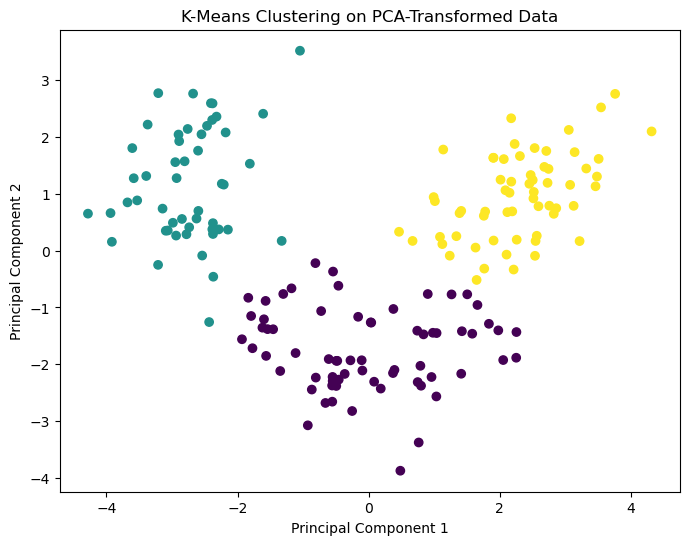

In [25]:
# Visualize PCA space clustering
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_labels, cmap='viridis')
plt.title("K-Means Clustering on PCA-Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

- The clusters formed using PCA-transformed data are clearly visible in the 2D plot. 
- The separation between clusters appears more distinct compared to clustering on the full original feature space.

In [26]:
# Evaluate clustering
sil_pca = silhouette_score(X_pca, pca_labels)
db_pca = davies_bouldin_score(X_pca, pca_labels)
print("PCA Data - Silhouette Score:", sil_pca)
print("PCA Data - Davies-Bouldin Index:", db_pca)

PCA Data - Silhouette Score: 0.5601697480957203
PCA Data - Davies-Bouldin Index: 0.5977226208167407


## Task 5: Comparison and Analysis:

In [28]:
print("----- Comparison -----")
print("Silhouette (Original):", sil_orig)
print("Silhouette (PCA):", sil_pca)
print("Davies-Bouldin (Original):", db_orig)
print("Davies-Bouldin (PCA):", db_pca)

if sil_pca > sil_orig and db_pca < db_orig:
    print("Clustering significantly improved after PCA.")
elif sil_pca > sil_orig:
    print("Clustering improved based on Silhouette score.")
else:
    print("Clustering performed better on original data.")

----- Comparison -----
Silhouette (Original): 0.2848589191898987
Silhouette (PCA): 0.5601697480957203
Davies-Bouldin (Original): 1.389187977718165
Davies-Bouldin (PCA): 0.5977226208167407
Clustering significantly improved after PCA.


- The silhouette score increased significantly from 0.28 to 0.56 after applying PCA, indicating better cluster separation.
- The Davies–Bouldin index decreased from 1.38 to 0.59, showing improved cluster compactness and reduced overlap.
- Therefore, PCA enhanced clustering performance by reducing noise and retaining the most important variance in the data.

**Interpretation Logic:**

- A higher Silhouette Score indicates that data points are well matched to their own cluster and clearly separated from other clusters.
- In contrast, a lower Davies–Bouldin Index suggests that clusters are more compact and distinct from one another.
- By analyzing these two metrics together, we can determine whether PCA improves the overall quality of clustering.

**Discussion of Similarities and Differences**

- Both the original and PCA data showed similar cluster patterns, meaning PCA kept the main structure of the data.
- However, clustering after PCA performed much better, with a higher silhouette score and lower Davies–Bouldin index.
- PCA also made visualization easier by reducing the data to fewer dimensions.
- Although some information may be lost, PCA improved clustering quality in this case.

#### Effect of Using PCA Before Clustering

- Using PCA decreased the number of features while still keeping most of the important information in the dataset.
- This made the clustering process simpler and more efficient. It also helped remove unnecessary or overlapping features, allowing clusters to become more clear and well separated.
- Another advantage is that PCA makes it easier to visualize the data in two dimensions using the main principal components.
- However, since PCA simplifies the data, some small details or complex patterns might be lost, which could affect clustering results in certain cases.

#### Comparing PCA-Based Clustering and Original Data Clustering

**Using PCA before clustering:**

- Makes the clustering process faster and more efficient
- Works well when features are highly correlated
- Makes visualization easier in lower dimensions
- May lose some detailed information during dimensionality reduction

**Clustering on the original dataset:**

- Keeps all the original information
- Can be slower, especially with many features
- May be more affected by noise or redundant variables
- Difficult to visualize when the data has many dimensions

## Conclusion and Insights

- Clustering on the original dataset used all available features and preserved complete information.
- In contrast, clustering on the PCA-transformed data was faster and produced clearer cluster separation.
- PCA simplified the dataset by reducing noise and redundant features, which improved clustering performance and visualization.
- Although some detailed information may be lost, PCA proved to be effective in enhancing overall cluster quality in this analysis.
- Overall, this analysis shows that PCA can significantly improve clustering performance when the dataset contains correlated or redundant features.